## Notebook 2: Estimating Stellar Parameters from Photometry

**Audience:** First-year PhD students in Astrophysics  
**Theme:** Scientific inference from noisy observables

###### Astrophysical motivation

A central task in stellar astrophysics is inferring physical stellar properties from observed light.

Ideally, one would use spectroscopy, which provides detailed diagnostics such as:

- effective temperature $T_{\rm eff}$
- surface gravity $\log g$
- metallicity $[{\rm Fe/H}]$
- radial velocity
- rotational broadening
- chemical abundances

However, spectroscopy is observationally expensive:
it requires more telescope time, complex reduction pipelines, and cannot be applied to all sources in large surveys.

By contrast, imaging surveys provide broadband photometry for millions to billions of stars
(e.g. SDSS, Pan-STARRS, Gaia, LSST/Rubin).

This leads to a central question:

> Can stellar effective temperature be inferred from photometric colours alone?

Classically, this is addressed using empirical colour–temperature relations.
Modern machine learning generalises this approach by enabling:

- multi-dimensional colour information
- nonlinear mappings
- uncertainty-aware regression
- regularised model fitting
- rigorous train/test validation

In this sense, machine learning in astronomy extends rather than replaces classical calibration techniques.

###### Learning goals

By the end of this notebook, you should understand:

- why stellar colours trace temperature
- limitations of single-colour estimators
- linear vs nonlinear regression
- heteroscedastic observational noise
- uncertainty-weighted fitting
- overfitting and regularisation
- residual analysis
- hidden-variable bias
- cross-validation principles

###### Core idea

Most astronomical regression problems can be viewed as:

> empirical calibration + statistical modelling + rigorous validation

## Imports

We use standard scientific Python libraries:

- **NumPy** for numerical arrays and random number generation  
- **Pandas** for tabular data handling  
- **Matplotlib / Seaborn** for visualization  
- **scikit-learn** for machine learning models and evaluation tools  

These provide the core infrastructure for data analysis, modelling, and validation in this notebook.

In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    KFold,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

import xgboost as xgb

## Reproducibility and readability

Fixing the random seed ensures that each run of the notebook produces the same synthetic catalogue and the same train/test split.

This is essential for debugging, teaching, and reproducible scientific analysis, where results must be comparable across runs and implementations.

In [2]:
SEED = 42
np.random.seed(SEED)

# Optional advanced sklearn configuration (only needed if metadata routing is used later)
sklearn.set_config(enable_metadata_routing=True)

# Plot styling chosen for readability and colorblind accessibility
plt.style.use("tableau-colorblind10")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

## Load the Dataset

In [3]:
import pandas as pd
import os

def load_and_validate_stellar_data(file_path):
    """
    Loads stellar photometry and performs multi-layer validation.
    """
    # 1. Systemic Error Handling (File Presence)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Critical Error: The file '{file_path}' was not found.")

    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        raise IOError(f"Failed to parse CSV: {e}")

    # 2. Structural Validation (Column presence)
    # These are essential for color-temperature inference
    required_columns = ["Teff", "u_g", "g_r", "r_i", "i_z", "feh", "sigma_phot"]
    missing_cols = [col for col in required_columns if col not in df.columns]
    
    if missing_cols:
        raise KeyError(f"Dataset is missing required astronomical features: {missing_cols}")

    # 3. Physical Validation (Filtering Non-Physical Artifacts)
    initial_count = len(df)

    # Drop any rows that have NaN in key features
    df = df.dropna(subset=required_columns)

    final_count = len(df)
    
    if final_count == 0:
        raise ValueError("Data validation failed: No valid stellar samples remain after filtering.")
    
    print(f"Successfully loaded {final_count} stars ({initial_count - final_count} rows discarded).")
    return df

    

In [4]:
# Execution
try:
    df = load_and_validate_stellar_data("sdss_raw_data_v1.csv")
except Exception as err:
    print(f"Pipeline Halted: {err}")


Successfully loaded 9000 stars (0 rows discarded).


In [5]:
#df = pd.read_csv("synthetic_stellar_data.csv")
#df.describe()


## Target transformation

In astronomy, stellar effective temperature is commonly expressed on a logarithmic scale. This is motivated by both physical interpretation and statistical convenience.

###### Hertzsprung–Russell diagram scaling

Many stellar properties (luminosity, radius, and colour) follow power-law relationships with temperature. As a result:

- A change from 3000 K to 4000 K corresponds to a major physical transition (e.g. M-dwarf to K-star)  
- A change from 23000 K to 24000 K represents a comparatively small shift in stellar properties  

Logarithmic scaling compresses large values and expands small values, reflecting this non-uniform physical sensitivity.

###### Relative vs absolute error

Machine learning models typically minimize mean squared error (MSE), which treats all absolute errors equally.

- In linear space:
  - A 500 K error is treated the same at 4000 K and at 40000 K, despite having very different physical significance  

- In log space:
  - The model effectively learns *relative (percentage) errors*  
  - An error of 0.02 dex corresponds to roughly a 4.6% multiplicative error, independent of temperature scale  

Here, “dex” refers to a decimal logarithmic unit (base-10 logarithm).

###### Distributional stability

Stellar temperature distributions in surveys are typically skewed, with a long tail toward very hot stars.

Applying $\log_{10}(T_{\rm eff})$:

- reduces skewness  
- stabilizes variance  
- often produces a more Gaussian-like target distribution  

This can improve optimization behaviour for many regression models.

Overall, logarithmic scaling encodes the fact that astrophysical relevance is often multiplicative rather than additive.

In [6]:
# Temperature often behaves more smoothly in logarithmic space.
# - relative errors matter more than absolute Kelvin errors
# - distributions are often better behaved
# - multiplicative trends become additive

df["log_Teff"] = np.log10(df["Teff"])


## Inspect the catalogue

In [7]:
df.describe()


,Teff,feh,logg,u_g,g_r,r_i,i_z,sigma_phot,log_Teff
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,5921.448036,-1.092936,3.887953,1.344204,0.470388,0.177754,0.083511,0.019008,3.766937
std,969.823210,0.640558,0.642054,0.432546,0.288319,0.153434,0.114872,0.016866,0.068256
min,4000.670000,-3.496656,0.536516,-0.368490,-0.198250,-2.375800,-0.994720,0.004258,3.602133
25%,5316.064750,-1.513437,3.671977,1.037535,0.294133,0.109138,0.028620,0.008724,3.725590
50%,5732.740000,-1.001560,4.064005,1.240185,0.464845,0.174925,0.075980,0.013492,3.758362
75%,6342.858500,-0.602233,4.320457,1.509960,0.586980,0.234433,0.125548,0.023057,3.802285
max,9417.772000,0.450219,4.881912,3.367600,2.199130,1.716090,2.618490,0.242745,3.973948


## Train / test split

We split the dataset into:

- **Training set:** used to fit model parameters  
- **Test set:** held back until the end for unbiased evaluation  

###### Why this is necessary

The goal is to prevent overfitting. A model can simply memorise the 3,000 synthetic stars without learning any underlying physical relationship.

Such memorisation would give excellent training performance but poor generalisation to new, unseen stars.

By evaluating on a held-out test set, we verify whether the model has learned a physically meaningful mapping between colours and temperature.

###### Target variable (y)

We use $\log_{10}(T_{\rm eff})$ as the target:

- This ensures that errors are interpreted in relative (percentage) terms  
- A 5% error at 4000 K is treated similarly to a 5% error at 8000 K  

###### Feature set (X)

We provide the model with four colour indices:

- $u-g$, $g-r$, $r-i$, $i-z$

While a single colour gives a rough estimate of temperature, multiple colours allow the model to disentangle effects such as dust reddening and metallicity, improving robustness and reducing degeneracies.

In [8]:
# Four colours help break degeneracies caused by dust and metallicity.

features = ["u_g", "g_r", "r_i", "i_z"]
X = df[features]
y = df["log_Teff"]


In [9]:
# test_size=0.25: You are hiding 25% of your stars in the test set
# random_state=SEED: This makes the experiment reproducible and we get the exact same stars in their training set.

X_train, X_test, y_train, y_test, sig_train, sig_test = train_test_split(
    X,
    y,
    df["sigma_phot"],
    test_size=0.25,
    random_state=SEED
)

print("Training stars:", len(X_train))
print("Test stars:", len(X_test))


Training stars: 6750
Test stars: 2250


## Inverse-variance weighting

In standard regression models, each data point contributes equally to the loss function.

However, in this dataset, some measurements are more reliable than others: bright, unreddened stars have small uncertainties, while faint or dusty stars are significantly noisier.

We incorporate this by using inverse-variance weighting based on photometric uncertainty:

$
w_{\text{train}} = \frac{1}{\sigma_{\text{train}}^2}
$

This reflects a standard principle in scientific inference: more precise measurements should contribute more strongly to parameter estimation.

###### Intuition

- If $\sigma_{\text{train}} = 0.01$, then $w = 10{,}000$
- If $\sigma_{\text{train}} = 0.2$, then $w = 25$

Thus, high-precision measurements dominate the optimisation, while noisy points have reduced influence.

###### Effect on learning

The model is therefore encouraged to prioritise fitting the most reliable data more accurately, rather than being driven by high-uncertainty observations.

This prevents low signal-to-noise measurements from disproportionately degrading model performance and aligns the training objective with measurement reliability.

In [10]:
# Avoid division by zero
sig_train_safe = np.clip(sig_train, 1e-4, None)
w_train = 1.0 / sig_train_safe**2
# Normalise weights (important for some models)
w_train = w_train / np.mean(w_train)

## Utility functions

We define standard regression metrics to compare model performance.

###### RMSE (Root Mean Squared Error)

RMSE penalises large errors more strongly because residuals are squared before averaging.

- Highly sensitive to outliers  
- If a model performs well on most stars but fails on a few extreme cases (e.g. highly reddened or noisy stars), RMSE will increase significantly  
- For Gaussian errors, RMSE is directly related to the standard deviation of the residuals  

###### MAE (Mean Absolute Error)

MAE measures the typical magnitude of prediction errors.

- More robust to outliers than RMSE  
- Interpreted as the expected absolute error for a random star in the sample  
- A large gap between RMSE and MAE can indicate the presence of a small number of severe prediction failures  

###### $R^2$ (Coefficient of determination)

$R^2$ measures the fraction of variance in the target explained by the model:

- $R^2 = 1$: perfect prediction  
- $R^2 = 0$: model performs no better than predicting the mean temperature  

Given the wide temperature range in the catalogue (3500 K to 9000 K), a high \(R^2\) indicates that the model has successfully learned the underlying temperature structure despite noise from dust, metallicity, and measurement uncertainty.

In [11]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "RMSE [dex]": rmse,
        "MAE [dex]": mae,
        "R2": r2
    }


## Multicolour linear regression

Here, we regard the Multicolour linear regression as our baseline.

In [12]:
lin4_model = LinearRegression()
lin4_model.fit(X_train, y_train, sample_weight=w_train)

lin4_pred = lin4_model.predict(X_test)

print(pd.Series(
    evaluate_model("Linear (4 colours)", y_test, lin4_pred)
))


Model         Linear (4 colours)
RMSE [dex]              0.033241
MAE [dex]               0.017288
R2                      0.764049
dtype: object


### Decision Trees (non-parametric models)

Stellar photometry–temperature relations are often nonlinear and affected by degeneracies, making simple linear models insufficient.

Decision trees address this by partitioning feature space into a hierarchy of decision rules rather than fitting a single global function.

The model works by:
- recursively splitting the data using thresholds in colour space  
- progressively grouping similar stars together  
- assigning a constant prediction within each terminal region (leaf)  

Each leaf effectively represents a local calibration of the colour–temperature relation.

###### What decision trees can capture

Decision trees can model:
- nonlinear dependencies between colours and temperature  
- separation between different stellar populations (e.g. dwarfs and giants)  
- effects of metallicity and interstellar reddening  
- mixed or multimodal stellar distributions  

###### Controlling overfitting

Because trees can easily overfit noise, we introduce regularisation through structural constraints:

- `max_depth`: limits how deep the tree can grow  
- `min_samples_leaf`: ensures each leaf contains enough data for stable estimates  
- `min_samples_split`: prevents splits driven by small, noisy subsets  

###### Interpretation

Unlike global regression models, decision trees replace a single functional form with a set of local rules learned directly from the data, making them flexible but requiring careful regularisation to avoid overfitting.

In [13]:
tree1_model = DecisionTreeRegressor(max_depth=2)
tree1_model.fit(X_train[["g_r"]], y_train, sample_weight=w_train)

tree1_pred = tree1_model.predict(X_test[["g_r"]])


[Text(0.5, 0.8333333333333334, 'x[0] <= 0.404\nsquared_error = 0.004\nsamples = 6750\nvalue = 3.776'),
 Text(0.25, 0.5, 'x[0] <= 0.225\nsquared_error = 0.003\nsamples = 2863\nvalue = 3.825'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.002\nsamples = 1059\nvalue = 3.874'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.001\nsamples = 1804\nvalue = 3.801'),
 Text(0.75, 0.5, 'x[0] <= 0.583\nsquared_error = 0.001\nsamples = 3887\nvalue = 3.736'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.001\nsamples = 2163\nvalue = 3.75'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.001\nsamples = 1724\nvalue = 3.71')]

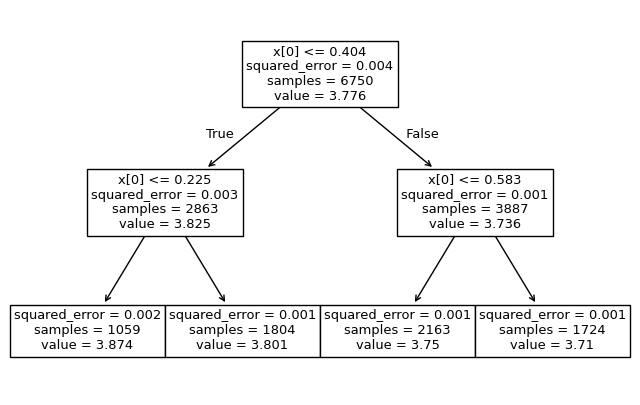

In [14]:
sklearn.tree.plot_tree(tree1_model)

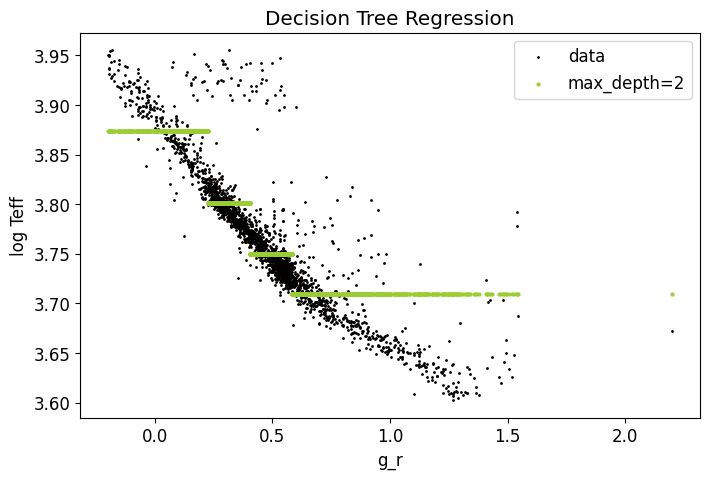

In [15]:
plt.figure()
plt.scatter(X_test[["g_r"]], y_test, s=1, edgecolor="black", c="darkorange", label="data")
plt.scatter(X_test[["g_r"]], tree1_pred, s=1,color="yellowgreen", label="max_depth=2", linewidth=2)
plt.xlabel("g_r")
plt.ylabel("log Teff")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

##  Decision Trees Regressor using all colors

In [16]:
tree4_model = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=42
)

tree4_model.fit(X_train, y_train, sample_weight=w_train)

tree4_pred = tree4_model.predict(X_test)

print(pd.Series(
    evaluate_model("Decision Tree (all colours)", y_test, tree4_pred)
))


Model         Decision Tree (all colours)
RMSE [dex]                       0.022238
MAE [dex]                        0.012972
R2                               0.894395
dtype: object


### Random Forest Regressor

A single decision tree is highly flexible but also unstable, meaning it can have high variance and be sensitive to small changes in the training data.

A Random Forest improves on this by combining many decision trees and averaging their predictions.

Each tree is trained using:
- a bootstrap sample of the data (random resampling with replacement)  
- a random subset of features at each split  

The final prediction is obtained by averaging the outputs of all individual trees.

###### Why this works

Averaging reduces variance: random fluctuations (noise) tend to cancel out across trees, while consistent physical signals are reinforced.

This leads to:
- lower variance than a single decision tree  
- improved stability of predictions  
- better generalisation to unseen data  

###### Robustness

Random Forests are particularly effective in astrophysical settings because they are robust to:
- noisy photometric measurements  
- extinction-induced variability  
- mixed stellar populations  
- moderate calibration systematics  

###### Interpretation

Random Forests can be seen as turning many weak, noisy decision trees into a single strong predictor through aggregation, improving reliability without requiring a parametric functional form.

In [17]:
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train, sample_weight=w_train)

rf_pred = rf_model.predict(X_test)

print(pd.Series(
    evaluate_model("Random Forest (all colours)", y_test, rf_pred)
))

Model         Random Forest (all colours)
RMSE [dex]                       0.018747
MAE [dex]                        0.011209
R2                               0.924949
dtype: object


## Gradient Boosting Regressor

Gradient Boosting builds an ensemble of decision trees in a sequential manner, where each new tree is trained to correct the errors made by the previous model.

Unlike Random Forests, which average independent trees, boosting improves performance iteratively.

The procedure is:

1. Start with an initial prediction (often a simple mean model)  
2. Compute residuals (errors)  
3. Train a new tree to predict these residuals  
4. Add the tree’s contribution to the current model  
5. Repeat the process over multiple iterations  

Each tree therefore focuses on the structure that previous trees failed to capture.

###### Why it works

By iteratively reducing residual errors, Gradient Boosting gradually improves the model’s ability to fit complex, nonlinear relationships.

It is particularly effective at capturing:

- subtle metallicity-dependent trends  
- weak nonlinearities in colour–temperature space  
- small systematic effects in photometric surveys  

###### Comparison with Random Forests

- **Random Forest:** reduces variance by averaging many independent trees  
- **Gradient Boosting:** reduces bias by sequentially correcting errors  

In practice, Gradient Boosting often achieves higher accuracy on structured tabular datasets, including astrophysical catalogues, but requires careful tuning to avoid overfitting.

In [18]:
gbr_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)

gbr_model.fit(X_train, y_train, sample_weight=w_train)

gbr_pred= gbr_model.predict(X_test)

print(pd.Series(
    evaluate_model("Gradient Boosting (all colours)", y_test, gbr_pred)
))

Model         Gradient Boosting (all colours)
RMSE [dex]                             0.0188
MAE [dex]                            0.011432
R2                                    0.92453
dtype: object


In [19]:
results = pd.DataFrame([
    evaluate_model("Linear (4 colours)", y_test, lin4_pred),
    evaluate_model("Decision Tree", y_test, tree4_pred),
    evaluate_model("Random Forest", y_test, rf_pred),
    evaluate_model("Gradient Boosting", y_test, gbr_pred)
])

results = results.sort_values("RMSE [dex]")
results


,Model,RMSE [dex],MAE [dex],R2
2,Random Forest,0.018747,0.011209,0.924949
3,Gradient Boosting,0.018800,0.011432,0.924530
1,Decision Tree,0.022238,0.012972,0.894395
0,Linear (4 colours),0.033241,0.017288,0.764049


## Model selection and cross-validation

Machine learning models involve two types of quantities:

- **Parameters:** learned from data during training (e.g. weights, tree splits)  
- **Hyperparameters:** chosen before training and control model complexity (e.g. depth, learning rate)  

> Parameters are learned; hyperparameters are chosen.

Using the test set for hyperparameter tuning leads to **data leakage**, producing overly optimistic performance estimates that do not generalise.

To avoid this, we separate the workflow into:

- **Training set:** used to learn model parameters  
- **Validation set:** used to tune hyperparameters and select models  
- **Test set:** used once at the end for an unbiased final evaluation  

The test set must remain completely unseen until the final evaluation step.

###### K-fold cross-validation

A single train/test split can produce noisy or unstable estimates depending on how the data is partitioned.

K-fold cross-validation provides a more robust evaluation procedure:

- Split the dataset into \(K\) subsets (folds)  
- Train on \(K-1\) folds and validate on the remaining fold  
- Repeat this process \(K\) times, each fold serving once as validation  
- Average the performance across all folds  

This reduces sensitivity to any particular data split and yields a more reliable estimate of generalisation performance.

###### Implementation detail (scikit-learn)

Scikit-learn maximises scores by default, so metrics such as RMSE are negated (e.g. `neg_root_mean_squared_error`).

- Lower RMSE is better → converted to a negative score for compatibility  
- Final results are converted back to RMSE for interpretation  

###### Interpretation

- Low variance across folds → stable, well-generalising model  
- High variance across folds → model may be unstable or overfitting  

Cross-validation therefore provides a more reliable estimate of predictive performance than a single train/test split by averaging results over multiple partitions of the data.

In [20]:
cv_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler().set_fit_request(sample_weight=False)),
    ("reg", Ridge(alpha=1.0).set_fit_request(sample_weight=True))
])

cv_results = cross_validate(
    cv_model, X_train, y_train, cv=5,
    scoring="neg_root_mean_squared_error",
    params={'sample_weight': w_train},
    return_train_score=True  
)

print("Train RMSE:", -cv_results['train_score'])
print("Val   RMSE:", -cv_results['test_score'])


Train RMSE: [0.03123823 0.03168963 0.03193297 0.03209861 0.03219151]
Val   RMSE: [0.0325576  0.0320238  0.03019326 0.06171551 0.03224237]


In [21]:
cv_model_retrain = sklearn.base.clone(cv_model)

cv_model_retrain.fit(
    X_train,
    y_train,
    sample_weight=w_train 
)

cv_pred = cv_model_retrain.predict(X_test)

res = evaluate_model("Ridge Poly", y_test, cv_pred)

print("Test RMSE:", round(res["RMSE [dex]"], 4))


Test RMSE: 0.034


## Random hyperparameter search across all models

To compare multiple candidate regressors fairly, we perform a **randomized hyperparameter search** over both model types and their associated regularisation/complexity parameters.

This approach is preferred over manual tuning because it:

- efficiently explores a wide hyperparameter space  
- applies consistent cross-validation across all models  
- reduces implicit researcher bias in model selection  
- often identifies strong configurations with fewer evaluations than exhaustive grid search  

In practice, this procedure treats model choice and hyperparameter tuning as a single unified optimisation problem.

For stellar calibration tasks with heteroscedastic noise, it is important that the scoring function reflects the scientific objective. Common choices include weighted RMSE, MAE, or \(R^2\), depending on whether the goal is accuracy, robustness, or explained variance.

In [22]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = "neg_root_mean_squared_error"

In [23]:
def poly_pipeline(reg):
    return Pipeline([
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scale", StandardScaler().set_fit_request(sample_weight=False)),
        ("reg", reg.set_fit_request(sample_weight=True))
    ])


models = {
    # -------------------------
    # Linear family (poly)
    # -------------------------
    "poly_linear": (
        poly_pipeline(LinearRegression()),
        {
            "poly__degree": [1,2,3,4]
        }
    ),

    "poly_ridge": (
        poly_pipeline(Ridge()),
        {
            "poly__degree": stats.randint(1, 5),
            "reg__alpha": stats.loguniform(1e1, 1e8)
        }
    ),

    "poly_lasso": (
        poly_pipeline(Lasso(max_iter=1000000)),
        {
            "poly__degree": stats.randint(1, 5),
            "reg__alpha": stats.loguniform(1e-6, 1e1)
        }
    ),

    # -------------------------
    # Trees
    # -------------------------
    "tree": (
        DecisionTreeRegressor(random_state=42).set_fit_request(sample_weight=True),
        {
            "max_depth": stats.randint(2, 20),
            "min_samples_leaf": stats.randint(2, 50),
            "min_samples_split": stats.randint(2, 100)
        }
    ),

    # -------------------------
    # Random Forest
    # -------------------------
    "rf": (
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ).set_fit_request(sample_weight=True),
        {
            "n_estimators": stats.randint(300, 800),
            "max_depth": stats.randint(3, 25),
            "min_samples_leaf": stats.randint(1, 30),
            "min_samples_split": stats.randint(2, 80),
            "max_features": ["sqrt", "log2", None]
        }
    ),

    # -------------------------
    # Gradient Boosting
    # -------------------------
    "gbr": (
        GradientBoostingRegressor(random_state=42).set_fit_request(sample_weight=True),
        {
            "n_estimators": stats.randint(300, 800),
            "learning_rate": stats.loguniform(0.005, 0.2),
            "max_depth": stats.randint(3, 8),
            "min_samples_leaf": stats.randint(1, 30),
        }
    )
}

In [ ]:
results = []

for name, (model, params) in models.items():
    if name=="poly_linear":
        search = GridSearchCV(
            estimator=model,
            param_grid=params,
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            verbose=1

        )
    else:    
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=params,
            n_iter=100,
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            random_state=42,
            verbose=1
        )

    search.fit(X_train, y_train, sample_weight=w_train)

    best_model = search.best_estimator_
    pred = best_model.predict(X_test)

    metrics = evaluate_model(name, y_test, pred)

    results.append({
        **metrics,
        "best_cv_score": -search.best_score_,
        "best_params": search.best_params_
    })

results_df = pd.DataFrame(results).sort_values("RMSE [dex]")


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits


/Users/marcoceloria/miniconda3/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.669e-02, tolerance: 2.086e-03
  model = cd_fast.enet_coordinate_descent(


In [ ]:
print(results_df[["Model", "RMSE [dex]", "MAE [dex]", "R2", "best_cv_score"]])


In [ ]:
for model_name, params in zip(results_df["Model"], results_df["best_params"]):
    print(f"{model_name}:")
    for k,v in params.items():
        print(f"\t{k}: {v}")
    print()

### Parity Plot (One-to-One)

This plot compares predicted values against true values to assess how well the model reproduces the underlying physical relationship.

In an ideal case, all points lie exactly on the 45° diagonal line, indicating perfect predictions.

###### 45° line (ideal reference)

- Points on the line → correct prediction  
- Points above the line → underprediction  
- Points below the line → overprediction  

###### Bias

Systematic deviations from the diagonal indicate model bias.

- Curvature away from the line, especially at the extremes, suggests the model performs poorly on rare or extreme values  
- Consistent offset from the diagonal indicates a systematic error in calibration  

###### Spread

The dispersion of points around the diagonal reflects predictive accuracy:

- tight clustering → low error, high precision  
- wide scatter → higher uncertainty and poorer performance  

###### Why this plot is useful

Unlike single summary metrics (e.g. RMSE or $R^2$), the parity plot reveals:

- where the model performs well or poorly across the target range  
- whether errors are systematic or random  
- how performance changes at the extremes of the distribution  

In [ ]:
rf_best_result = next(r for r in results if r["Model"] == "rf")
best_rf_params = rf_best_result["best_params"]

rf_best = RandomForestRegressor(
    **best_rf_params,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train, y_train, sample_weight=w_train)

rf_best_pred = rf_best.predict(X_test)


In [ ]:
plt.scatter(rf_best_pred, y_test, s=10, alpha=0.3)
plt.xlabel("Predicted log(Teff)")
plt.ylabel("True log(Teff)")
plt.title("Random Forest Mean Prediction")
plt.tight_layout()
plt.show()


### Residual diagnostics

Summary metrics such as RMSE and $R^2$ can hide important structure in model errors. Residual plots help reveal systematic patterns that scalar metrics miss.

The residual is defined as:

$
\text{residual} = y - \hat{y}
$

- \(< 0\): overprediction  
- \(> 0\): underprediction  

###### What residuals reveal

Residuals allow us to assess whether errors are random or structured across the target range.

- **Good model:** residuals are randomly scattered around zero  
- **Bad model:** residuals show trends, curvature, or clustering → indicates missing physics or model misspecification  

###### Distributional behaviour

- **Centered at 0:** no global bias in predictions  
- **Shifted mean:** systematic over- or underprediction  
- **Narrow distribution:** high precision overall  
- **Wide distribution / heavy tails:** presence of difficult or rare cases with large errors  

###### Interpretation

A well-performing model produces residuals that resemble random noise.

In contrast, structured residual patterns indicate that the model is failing to capture aspects of the underlying physical relationship, even if global metrics such as RMSE appear acceptable.

In [ ]:
#resid = pred_ridge - y_test
resid = y_test - rf_best_pred
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].scatter(y_test, resid, s=10, alpha=0.3)
ax[0].axhline(0, ls="--")
ax[0].set_xlabel("True log(Teff)")
ax[0].set_ylabel("Residual [dex]")
ax[0].set_title("Residual Trend")

ax[1].hist(resid, bins=30)
ax[1].set_xlabel("Residual [dex]")
ax[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()



### Hidden-variable check: metallicity

Residuals are not purely random because some relevant physical variables were not included in the model.

In this case, **metallicity ($[{\rm Fe/H}]$) affects stellar colours**, but it was not explicitly provided as an input feature.

This diagnostic tests whether prediction errors depend on stellar chemistry.

- **X-axis:** metallicity $[{\rm Fe/H}]$  
- **Y-axis:** residuals ($y - \hat{y}$)  

###### What we are testing

We are checking whether model errors are systematically correlated with metallicity.

###### Interpretation

- **Flat distribution around zero:** good → no detectable metallicity bias  
- **Clear trend or slope:** bad → systematic under/overprediction for metal-rich or metal-poor stars  

###### Physical meaning

Since the model only uses photometric colours, any dependence of residuals on $[{\rm Fe/H}]$ indicates that metallicity introduces a hidden degeneracy in colour–temperature space that the model cannot fully resolve.

This reveals that metallicity is an important latent variable in the mapping from colours to stellar temperature.

In [ ]:
feh_test = df.loc[X_test.index, "feh"]

plt.scatter(feh_test, resid, s=10, alpha=0.3)
plt.axhline(0, ls="--")
plt.xlabel("[Fe/H]")
plt.ylabel("Residual [dex]")
plt.title("Residuals vs Metallicity")
plt.tight_layout()
plt.show()


# Scientific interpretation

This notebook demonstrates how stellar effective temperatures can be inferred from photometric data using progressively more sophisticated statistical models.

###### Main conclusions

- **Photometric colours contain physical information about stellar temperature**  
  The mapping between colour indices and \(T_{\rm eff}\) is real and physically grounded in stellar emission physics.

- **Multi-band photometry improves inference**  
  Using multiple filters (instead of a single colour) significantly improves performance by providing additional constraints and reducing degeneracies.

- **Nonlinear models are necessary to capture astrophysical structure**  
  The true colour–temperature relation is curved, so nonlinear methods better represent stellar physics than purely linear models.

- **Uncertainty quantification is essential**  
  Reliable scientific inference requires not only predictions but also well-calibrated uncertainties.

- **Hidden variables introduce systematic bias**  
  Physical effects such as metallicity and interstellar extinction can bias predictions if not explicitly modelled.

- **Validation is critical for scientific reliability**  
  Cross-validation and held-out test sets are necessary to ensure that results generalise beyond the training data.

###### Overall message

Accurate stellar inference is not only a regression problem, but a full statistical modelling problem involving:
- signal extraction from noisy data  
- disentangling correlated physical effects  
- and rigorous evaluation of predictive uncertainty and generalisation

## Exercises

These exercises extend the notebook toward more realistic and advanced astrophysical inference problems.

###### 1. Add metallicity as a feature

Include $[{\rm Fe/H}]$ in the feature set and evaluate how much predictive performance improves.

- quantify changes in RMSE, $R^2$, and calibration  
- assess whether residual–metallicity correlations disappear  
- interpret the reduction in degeneracy between colour and chemistry  

###### 2. Compare $T_{\rm eff}$ vs $\log_{10}(T_{\rm eff})$

Train models on both target representations and compare:

- numerical stability  
- error behaviour across temperature ranges  
- whether log-space improves relative accuracy  

###### 3. Quantile regression vs Random Forest uncertainty

Replace Random Forest uncertainty (tree spread) with quantile regression intervals:

- compare calibration (coverage vs nominal confidence)  
- evaluate sharpness vs reliability trade-offs  
- assess whether intervals better reflect true error structure  

###### 4. Gaussian Process regression

Apply Gaussian Process regression and compare:

- predictive performance  
- uncertainty quality (posterior variance)  
- computational scalability limitations  

###### 5. Add Gaia information

Incorporate additional astrophysical constraints such as:

- parallax (distance information)  
- luminosity estimates  

and evaluate how breaking degeneracies improves temperature inference.

###### 6. Selection bias experiments

Introduce controlled selection effects (e.g. magnitude cuts or incomplete sampling) and analyse:

- how training distribution mismatch affects predictions  
- whether models extrapolate or fail under biased sampling  
- robustness of different algorithms to observational selection effects  

###### Overall goal

These exercises aim to move from supervised regression toward **physically informed statistical inference under realistic observational constraints**.

## Final takeaway

Stellar parameter inference is not simply a regression task.

It is fundamentally a problem of:

> probabilistic estimation from noisy, biased, and incomplete observations

### Core idea

The goal is not only to predict stellar properties, but to do so in a way that is statistically consistent with the limitations of the data.

###### What good astrophysical machine learning requires

Effective models combine:

- **Physical intuition**  
  Encoding known relationships such as stellar spectra, extinction laws, and population structure  

- **Statistical discipline**  
  Proper handling of noise, heteroscedasticity, and model complexity  

- **Careful validation**  
  Use of train/test separation and cross-validation to ensure generalisation  

- **Uncertainty quantification**  
  Providing calibrated confidence estimates, not just point predictions  

### Final message

Reliable astrophysical inference requires moving beyond “best-fit prediction” toward models that:
- understand the structure of the data  
- respect observational limitations  
- and express uncertainty honestly and quantitatively  